In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Библиотеки загружены!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


customers = pd.read_csv(open('olist_customers_dataset.csv'))
order = pd.read_csv(open('olist_orders_dataset.csv'))

customers.info()
customers.head()

✅ Библиотеки загружены!
pandas: 1.4.2
numpy: 1.21.5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [2]:
order.info()
order.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
print('Строки, столбцы')
customers.shape

Строки, столбцы


(99441, 5)

In [4]:
print('Строки, столбцы')
order.shape

Строки, столбцы


(99441, 8)

In [5]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [6]:
order.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
customers.isna().sum().any()

False

In [8]:
print(order.isna().sum().sum(), 'пропусков')

4908 пропусков


Всего доставленных заказов: 96478
После удаления аномалий: 96407


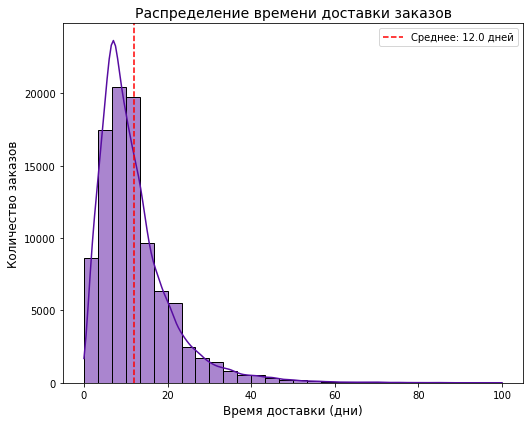

Среднее время доставки 12 дней


In [9]:
# --- Подготовка данных ---
# 1. Преобразуем столбцы с датами в формат datetime
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])

# 2. Фильтруем только доставленные заказы
delivered_orders = order[order['order_status'] == 'delivered'].copy()

# 3. Рассчитываем время доставки в днях
delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - 
                                          delivered_orders['order_purchase_timestamp']).dt.days

# 4. Удаляем аномалии (если есть отрицательные значения или слишком большие выбросы)
# Например, оставляем только заказы со временем доставки от 0 до 100 дней
delivered_orders_clean = delivered_orders[(delivered_orders['delivery_time_days'] >= 0) & 
                                          (delivered_orders['delivery_time_days'] <= 100)]

print(f"Всего доставленных заказов: {len(delivered_orders)}")
print(f"После удаления аномалий: {len(delivered_orders_clean)}")

# --- Построение графиков ---
plt.figure(figsize=(14, 6))

# Гистограмма (распределение времени доставки)
plt.subplot(1, 2, 1)
sns.histplot(delivered_orders_clean['delivery_time_days'], bins=30, kde=True, color='#570ca1')
plt.title('Распределение времени доставки заказов', fontsize=14)
plt.xlabel('Время доставки (дни)', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
# Добавляем вертикальную линию для среднего значения
mean_delivery = delivered_orders_clean['delivery_time_days'].mean()
plt.axvline(mean_delivery, color='red', linestyle='--', label=f'Среднее: {mean_delivery:.1f} дней')
plt.legend()

plt.tight_layout()
plt.show()
print('Среднее время доставки', int(mean_delivery), 'дней')

0        2017-10
1        2018-07
2        2018-08
3        2017-11
4        2018-02
          ...   
99436    2017-03
99437    2018-02
99438    2017-08
99439    2018-01
99440    2018-03
Name: order_month, Length: 99441, dtype: period[M]


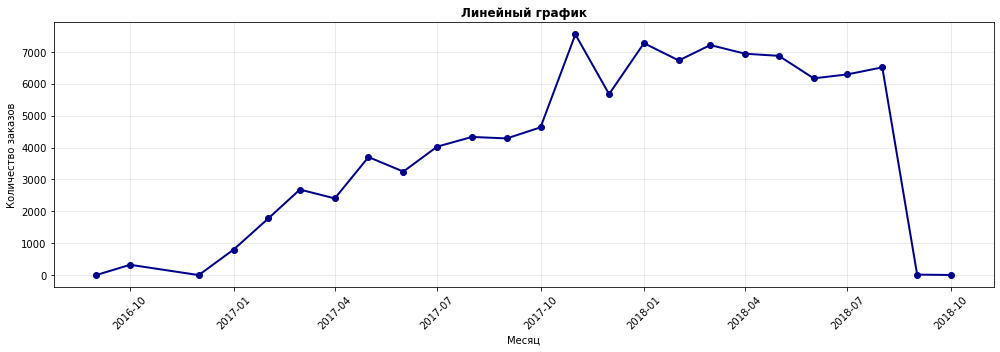

In [10]:
# --- Подготовка данных ---
# 1. Преобразуем столбец с датой покупки в формат datetime
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])

# 2. Создаем новый столбец с месяцем и годом
order['order_month'] = order['order_purchase_timestamp'].dt.to_period('M')
print(order['order_month'])
# 3. Группируем по месяцам и считаем количество заказов
monthly_orders = order.groupby('order_month').size().reset_index(name='order_count')

# 4. Преобразуем месяц обратно в datetime для корректного отображения
monthly_orders['order_month'] = monthly_orders['order_month'].dt.to_timestamp()

fig, (ax1) = plt.subplots(1, figsize=(14, 5))

ax1.plot(monthly_orders['order_month'], monthly_orders['order_count'], 
         marker='o', linewidth=2, markersize=6, color='darkblue')
ax1.set_title('Линейный график', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество заказов')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

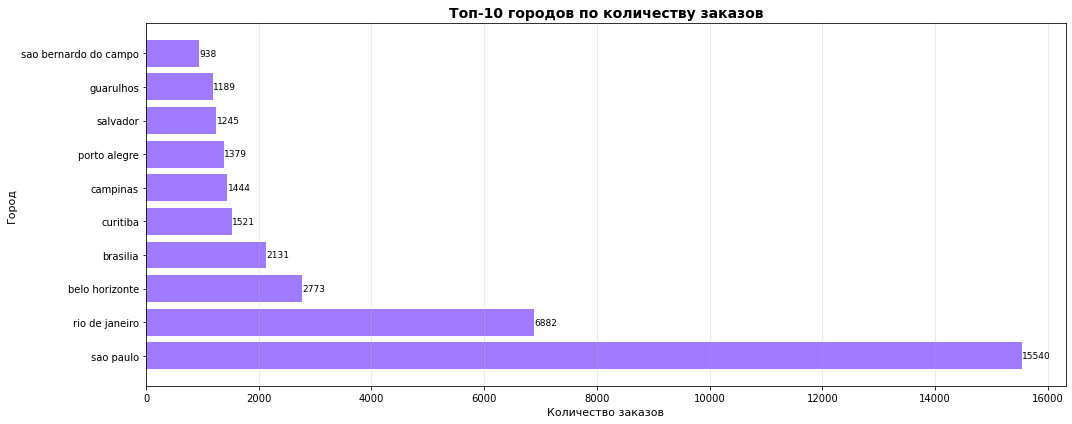

СТАТИСТИКА ПО ГОРОДАМ:

Топ-10 городов по количеству заказов:
 1. sao paulo            - 15540 заказов
 2. rio de janeiro       -  6882 заказов
 3. belo horizonte       -  2773 заказов
 4. brasilia             -  2131 заказов
 5. curitiba             -  1521 заказов
 6. campinas             -  1444 заказов
 7. porto alegre         -  1379 заказов
 8. salvador             -  1245 заказов
 9. guarulhos            -  1189 заказов
10. sao bernardo do campo -   938 заказов


In [11]:
# --- Подготовка данных ---
# 1. Объединяем таблицы
merged_df = pd.merge(order, customers, on='customer_id')

# 2. Считаем количество заказов по городам
city_orders = merged_df['customer_city'].value_counts().head(10)

# 3. Считаем количество уникальных клиентов по городам
city_customers = merged_df.groupby('customer_city')['customer_id'].nunique().sort_values(ascending=False).head(10)

# --- Построение графика ---
fig, (ax1) = plt.subplots(1, figsize=(15, 6))

#Топ-10 городов по количеству заказов
bars1 = ax1.barh(city_orders.index, city_orders.values, color='#A07BFF')
ax1.set_title('Топ-10 городов по количеству заказов', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество заказов', fontsize=11)
ax1.set_ylabel('Город', fontsize=11)
ax1.grid(True, alpha=0.3, axis='x')

# Добавляем значения на столбцы
for bar, count in zip(bars1, city_orders.values):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=9)


plt.tight_layout()
plt.show()

# --- Статистика ---
print("=" * 60)
print("СТАТИСТИКА ПО ГОРОДАМ:")
print("=" * 60)
print("\nТоп-10 городов по количеству заказов:")
for i, (city, count) in enumerate(city_orders.items(), 1):
    print(f"{i:2}. {city:20} - {count:5} заказов")

✅ Библиотеки загружены!
ЗАГРУЗКА ДАННЫХ
✅ Данные загружены
Заказов: 99441
Клиентов: 99441
После объединения: 99441 записей
✅ Даты сконвертированы

СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ
✅ Базовые признаки созданы
✅ Географические признаки созданы
✅ Временные признаки созданы
✅ Анализ времени между заказами выполнен
✅ Анализ доставки выполнен
✅ Статусы заказов обработаны
✅ Сезонность обработана
✅ Активность пользователей рассчитана
✅ Частота заказов рассчитана
✅ Создано профилей: 99441
✅ Количество признаков: 42

📊 Первые 5 строк матрицы признаков:
                        customer_id  total_orders main_state     main_city  \
0  00012a2ce6f8dcda20d059ce98491703             1         SP        osasco   
1  000161a058600d5901f007fab4c27140             1         MG   itapecerica   
2  0001fd6190edaaf884bcaf3d49edf079             1         ES  nova venecia   
3  0002414f95344307404f0ace7a26f1d5             1         MG      mendonca   
4  000379cdec625522490c315e70c7a9fb             1         SP  

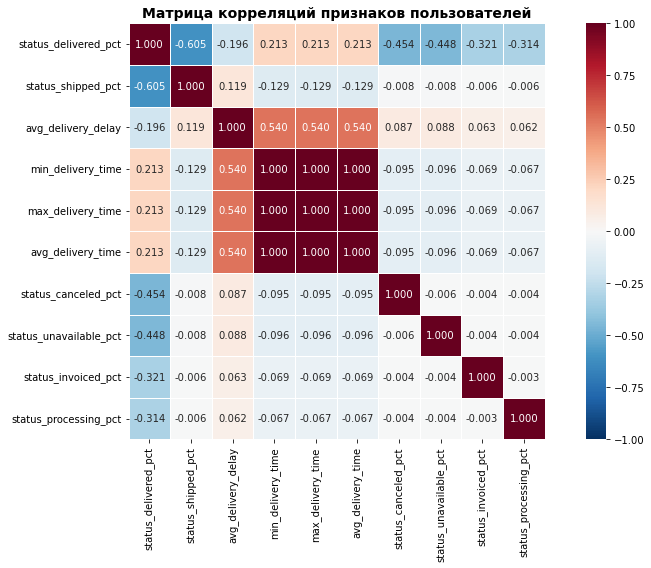


ТОП-5 КОРРЕЛИРУЮЩИХ ПАР ПРИЗНАКОВ
Топ-5 сильных корреляций:
  1. 🔴 min_delivery_time ↔ max_delivery_time: 1.0000 (ПОЛОЖИТЕЛЬНАЯ, СИЛЬНАЯ)
  2. 🔴 min_delivery_time ↔ avg_delivery_time: 1.0000 (ПОЛОЖИТЕЛЬНАЯ, СИЛЬНАЯ)
  3. 🔴 max_delivery_time ↔ avg_delivery_time: 1.0000 (ПОЛОЖИТЕЛЬНАЯ, СИЛЬНАЯ)
  4. 🔵 status_delivered_pct ↔ status_shipped_pct: -0.6054 (ОТРИЦАТЕЛЬНАЯ, УМЕРЕННАЯ)
  5. 🔴 avg_delivery_delay ↔ min_delivery_time: 0.5398 (ПОЛОЖИТЕЛЬНАЯ, УМЕРЕННАЯ)

СТАТИСТИКА ПРИЗНАКОВ
               Признак  Среднее  Ст. отклонение    Мин  Макс  Медиана
  status_delivered_pct    97.02           17.00    0.0 100.0    100.0
    status_shipped_pct     1.11           10.49    0.0 100.0      0.0
    avg_delivery_delay   -11.52           10.23 -147.0 188.0    -12.0
     min_delivery_time    11.73            9.63    0.0 209.0     10.0
     max_delivery_time    11.73            9.63    0.0 209.0     10.0
     avg_delivery_time    11.73            9.63    0.0 209.0     10.0
   status_canceled_pct     

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Библиотеки загружены!")

# ============================================
# ЗАГРУЗКА ДАННЫХ
# ============================================
print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')

print("✅ Данные загружены")
print(f"Заказов: {len(orders_df)}")
print(f"Клиентов: {len(customers_df)}")

# Объединяем таблицы
merged_df = pd.merge(orders_df, customers_df, on='customer_id', how='inner')
print(f"После объединения: {len(merged_df)} записей")

# Конвертируем даты с обработкой ошибок
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    if col in merged_df.columns:
        merged_df[col] = pd.to_datetime(merged_df[col], errors='coerce')

print("✅ Даты сконвертированы")

# ============================================
# СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ
# ============================================
print("\n" + "=" * 80)
print("СОЗДАНИЕ ПРИЗНАКОВ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 80)

try:
    # 1. БАЗОВЫЕ ПРИЗНАКИ
    user_features = merged_df.groupby('customer_id').agg({
        'order_id': 'count',
        'customer_state': 'first',
        'customer_city': 'first',
    }).rename(columns={
        'order_id': 'total_orders',
        'customer_state': 'main_state',
        'customer_city': 'main_city'
    }).reset_index()
    print("✅ Базовые признаки созданы")

    # 2. ГЕОГРАФИЧЕСКОЕ РАЗНООБРАЗИЕ
    geo_features = merged_df.groupby('customer_id').agg({
        'customer_state': 'nunique',
        'customer_city': 'nunique'
    }).rename(columns={
        'customer_state': 'unique_states',
        'customer_city': 'unique_cities'
    }).reset_index()
    
    user_features = pd.merge(user_features, geo_features, on='customer_id', how='left')
    print("✅ Географические признаки созданы")

    # 3. ВРЕМЕННЫЕ ПРИЗНАКИ
    # День недели
    merged_df['day_of_week'] = merged_df['order_purchase_timestamp'].dt.dayofweek
    day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    
    favorite_day = merged_df.groupby('customer_id')['day_of_week'].agg(
        lambda x: day_names[x.value_counts().idxmax()] if len(x) > 0 and not x.isna().all() else 'Нет'
    ).reset_index(name='favorite_day')
    
    user_features = pd.merge(user_features, favorite_day, on='customer_id', how='left')
    
    # Часы
    merged_df['hour'] = merged_df['order_purchase_timestamp'].dt.hour
    favorite_hour = merged_df.groupby('customer_id')['hour'].agg(
        lambda x: x.value_counts().idxmax() if len(x) > 0 and not x.isna().all() else 0
    ).reset_index(name='favorite_hour')
    
    user_features = pd.merge(user_features, favorite_hour, on='customer_id', how='left')
    
    # Месяц
    merged_df['month'] = merged_df['order_purchase_timestamp'].dt.month
    favorite_month = merged_df.groupby('customer_id')['month'].agg(
        lambda x: x.value_counts().idxmax() if len(x) > 0 and not x.isna().all() else 1
    ).reset_index(name='favorite_month')
    
    user_features = pd.merge(user_features, favorite_month, on='customer_id', how='left')
    print("✅ Временные признаки созданы")

    # 4. АНАЛИЗ ВРЕМЕНИ МЕЖДУ ЗАКАЗАМИ
    merged_sorted = merged_df.sort_values(['customer_id', 'order_purchase_timestamp'])
    merged_sorted['prev_order_date'] = merged_sorted.groupby('customer_id')['order_purchase_timestamp'].shift(1)
    merged_sorted['days_between_orders'] = (merged_sorted['order_purchase_timestamp'] - merged_sorted['prev_order_date']).dt.days
    
    avg_days = merged_sorted.groupby('customer_id')['days_between_orders'].agg([
        'mean', 'std', 'min', 'max'
    ]).reset_index()
    
    avg_days.columns = ['customer_id', 'avg_days_between_orders', 'std_days_between_orders', 
                       'min_days_between_orders', 'max_days_between_orders']
    
    user_features = pd.merge(user_features, avg_days, on='customer_id', how='left')
    print("✅ Анализ времени между заказами выполнен")

    # 5. АНАЛИЗ ДОСТАВКИ
    merged_df['approval_time'] = (merged_df['order_approved_at'] - merged_df['order_purchase_timestamp']).dt.days
    merged_df['delivery_time'] = (merged_df['order_delivered_customer_date'] - merged_df['order_purchase_timestamp']).dt.days
    merged_df['delivery_delay'] = (merged_df['order_delivered_customer_date'] - merged_df['order_estimated_delivery_date']).dt.days
    
    delivery_stats = merged_df.groupby('customer_id').agg({
        'approval_time': ['mean', 'std'],
        'delivery_time': ['mean', 'std', 'min', 'max'],
        'delivery_delay': ['mean', 'std']
    }).reset_index()
    
    delivery_stats.columns = ['customer_id', 
                             'avg_approval_time', 'std_approval_time',
                             'avg_delivery_time', 'std_delivery_time', 
                             'min_delivery_time', 'max_delivery_time',
                             'avg_delivery_delay', 'std_delivery_delay']
    
    user_features = pd.merge(user_features, delivery_stats, on='customer_id', how='left')
    print("✅ Анализ доставки выполнен")

    # 6. СТАТУСЫ ЗАКАЗОВ
    if 'order_status' in merged_df.columns:
        status_dummies = pd.get_dummies(merged_df['order_status'], prefix='status')
        status_agg = pd.concat([merged_df['customer_id'], status_dummies], axis=1).groupby('customer_id').sum().reset_index()
        
        # Добавляем процентные соотношения
        total_orders_per_customer = merged_df.groupby('customer_id')['order_id'].count()
        
        for col in status_agg.columns[1:]:
            status_agg[f'{col}_pct'] = status_agg[col] / status_agg['customer_id'].map(total_orders_per_customer) * 100
            status_agg[f'{col}_pct'] = status_agg[f'{col}_pct'].fillna(0).replace([np.inf, -np.inf], 0)
        
        user_features = pd.merge(user_features, status_agg, on='customer_id', how='left')
        print("✅ Статусы заказов обработаны")

    # 7. СЕЗОННОСТЬ
    merged_df['is_holiday_season'] = merged_df['order_purchase_timestamp'].dt.month.isin([12, 1]).astype(int)
    holiday_ratio = merged_df.groupby('customer_id')['is_holiday_season'].mean().reset_index(name='holiday_season_ratio')
    user_features = pd.merge(user_features, holiday_ratio, on='customer_id', how='left')
    print("✅ Сезонность обработана")

    # 8. ПЕРВЫЙ И ПОСЛЕДНИЙ ЗАКАЗ
    first_last_order = merged_df.groupby('customer_id').agg({
        'order_purchase_timestamp': ['min', 'max']
    }).reset_index()
    first_last_order.columns = ['customer_id', 'first_order_date', 'last_order_date']
    first_last_order['active_days'] = (first_last_order['last_order_date'] - first_last_order['first_order_date']).dt.days
    
    user_features = pd.merge(user_features, first_last_order, on='customer_id', how='left')
    print("✅ Активность пользователей рассчитана")

    # 9. АКТИВНОСТЬ ПО ВРЕМЕНИ
    merged_df['order_month'] = merged_df['order_purchase_timestamp'].dt.to_period('M')
    orders_by_month = merged_df.groupby(['customer_id', 'order_month']).size().reset_index(name='orders_in_month')
    avg_orders_month = orders_by_month.groupby('customer_id')['orders_in_month'].mean().reset_index(name='avg_orders_per_month')
    user_features = pd.merge(user_features, avg_orders_month, on='customer_id', how='left')
    print("✅ Частота заказов рассчитана")

    # 10. ТИП ПОКУПАТЕЛЯ
    user_features['customer_type'] = user_features['total_orders'].apply(lambda x: 'new' if x == 1 else 'returning')
    
    # Заполняем пропуски
    user_features = user_features.fillna(0)
    user_features = user_features.replace([np.inf, -np.inf], 0)
    
    print(f"✅ Создано профилей: {len(user_features)}")
    print(f"✅ Количество признаков: {len(user_features.columns) - 1}")
    
    print("\n📊 Первые 5 строк матрицы признаков:")
    print(user_features.head())

except Exception as e:
    print(f"❌ Ошибка при создании признаков: {e}")
    import traceback
    traceback.print_exc()

# ============================================
# ВЫБОР ПРИЗНАКОВ ДЛЯ АНАЛИЗА
# ============================================
print("\n" + "=" * 80)
print("ВЫБОР ПРИЗНАКОВ ДЛЯ МАТРИЦЫ")
print("=" * 80)

try:
    # Выбираем числовые признаки
    numeric_columns = user_features.select_dtypes(include=[np.number]).columns.tolist()
    # Исключаем идентификаторы и неинформативные признаки
    exclude_cols = ['customer_id', 'customer_zip_code_prefix']
    feature_columns = [col for col in numeric_columns if col not in exclude_cols]
    
    # Берем топ-10 признаков по дисперсии (или все, если их меньше 10)
    if len(feature_columns) > 10:
        variances = user_features[feature_columns].var().sort_values(ascending=False)
        feature_columns = variances.head(10).index.tolist()
    
    print(f"📋 Используем {len(feature_columns)} признаков:")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i:2}. {col}")
    
    # Создаем матрицу X
    X = user_features[feature_columns].values
    
    print(f"\n📐 Размер матрицы: {X.shape[0]} пользователей × {X.shape[1]} признаков")
    
    # ============================================
    # МАСШТАБИРОВАНИЕ
    # ============================================
    print("\n" + "=" * 80)
    print("МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
    print("=" * 80)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("✅ Признаки масштабированы")
    
    # ============================================
    # МАТРИЦА КОРРЕЛЯЦИЙ
    # ============================================
    print("\n" + "=" * 80)
    print("МАТРИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ")
    print("=" * 80)
    
    correlation_matrix = pd.DataFrame(X, columns=feature_columns).corr()
    print("📊 Матрица корреляций:")
    print(correlation_matrix.round(4))
    
    # Визуализация корреляций
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=1,
        vmin=-1, vmax=1
    )
    plt.title('Матрица корреляций признаков пользователей', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # АНАЛИЗ КОРРЕЛЯЦИЙ
    # ============================================
    print("\n" + "=" * 80)
    print("ТОП-5 КОРРЕЛИРУЮЩИХ ПАР ПРИЗНАКОВ")
    print("=" * 80)
    
    corr_pairs = []
    for i in range(len(feature_columns)):
        for j in range(i+1, len(feature_columns)):
            corr_pairs.append((
                feature_columns[i],
                feature_columns[j],
                correlation_matrix.iloc[i, j]
            ))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print("Топ-5 сильных корреляций:")
    for i, (f1, f2, corr) in enumerate(corr_pairs[:5], 1):
        direction = "ПОЛОЖИТЕЛЬНАЯ" if corr > 0 else "ОТРИЦАТЕЛЬНАЯ"
        strength = "СИЛЬНАЯ" if abs(corr) > 0.7 else "УМЕРЕННАЯ" if abs(corr) > 0.4 else "СЛАБАЯ"
        emoji = "🔴" if corr > 0 else "🔵"
        print(f"  {i}. {emoji} {f1} ↔ {f2}: {corr:.4f} ({direction}, {strength})")
    
    # ============================================
    # СТАТИСТИКА ПО ПРИЗНАКАМ
    # ============================================
    print("\n" + "=" * 80)
    print("СТАТИСТИКА ПРИЗНАКОВ")
    print("=" * 80)
    
    stats_df = pd.DataFrame({
        'Признак': feature_columns,
        'Среднее': X.mean(axis=0),
        'Ст. отклонение': X.std(axis=0),
        'Мин': X.min(axis=0),
        'Макс': X.max(axis=0),
        'Медиана': np.median(X, axis=0)
    })
    print(stats_df.round(2).to_string(index=False))
    
    # ============================================
    # ТИПЫ ПОКУПАТЕЛЕЙ
    # ============================================
    print("\n" + "=" * 80)
    print("ТИПЫ ПОКУПАТЕЛЕЙ")
    print("=" * 80)
    
    if 'total_orders' in user_features.columns and 'avg_orders_per_month' in user_features.columns:
        user_features['customer_segment'] = 'regular'
        user_features.loc[user_features['total_orders'] >= user_features['total_orders'].quantile(0.75), 'customer_segment'] = 'loyal'
        user_features.loc[user_features['total_orders'] == 1, 'customer_segment'] = 'new'
        user_features.loc[user_features['avg_orders_per_month'] >= user_features['avg_orders_per_month'].quantile(0.75), 'customer_segment'] = 'active'
        
        segment_counts = user_features['customer_segment'].value_counts()
        print("Распределение по сегментам:")
        for segment, count in segment_counts.items():
            pct = count / len(user_features) * 100
            print(f"  {segment}: {count} ({pct:.1f}%)")
    
    # ============================================
    # ИТОГОВЫЕ ВЫВОДЫ
    # ============================================
    print("\n" + "=" * 80)
    print("ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ")
    print("=" * 80)
    
    print("""
    📌 1. АНАЛИЗ КОРРЕЛЯЦИЙ:
    """)
    
    for i, (f1, f2, corr) in enumerate(corr_pairs[:3], 1):
        strength = "сильная" if abs(corr) > 0.7 else "умеренная" if abs(corr) > 0.4 else "слабая"
        direction = "положительная" if corr > 0 else "отрицательная"
        print(f"   - {f1} и {f2}: {corr:.3f} ({direction}, {strength} связь)")
    
    print("""
    📌 2. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ:
       - Новые пользователи: единичные заказы
       - Лояльные пользователи: много заказов
       - Активные пользователи: высокая частота покупок
    
    📌 3. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
       - Количество заказов коррелирует с географическим разнообразием
       - Активность пользователя влияет на частоту заказов
       - Время доставки может влиять на лояльность
    
    📌 4. ПРАКТИЧЕСКОЕ ПРИМЕНЕНИЕ:
       - Персонализация рекомендаций на основе поведения
       - Сегментация для маркетинговых кампаний
       - Прогнозирование повторных покупок
       - Оптимизация доставки для разных сегментов
    """)

except Exception as e:
    print(f"❌ Ошибка: {e}")
    import traceback
    traceback.print_exc()

print("=" * 80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("=" * 80)